In [2]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(42)
n = 50000  # 50,000 transactions

# Time range: last 6 months
start_date = datetime(2024, 10, 1)
dates = [start_date + timedelta(minutes=random.randint(0, 180*24*60)) for _ in range(n)]

df = pd.DataFrame({
    "transaction_id":   [f"TXN{str(i).zfill(8)}" for i in range(n)],
    "timestamp":        dates,
    "amount":           np.round(np.random.exponential(scale=1500, size=n), 2),
    "sender_bank":      np.random.choice(["HDFC", "SBI", "ICICI", "Axis", "Kotak"], n, p=[0.30, 0.25, 0.20, 0.15, 0.10]),
    "receiver_bank":    np.random.choice(["HDFC", "SBI", "ICICI", "Axis", "Kotak"], n),
    "merchant_category":np.random.choice(["Food", "Retail", "Travel", "Utilities", "Healthcare", "Entertainment"], n),
    "status":           np.random.choice(["SUCCESS", "FAILED", "PENDING"], n, p=[0.88, 0.09, 0.03]),
    "city":             np.random.choice(["Mumbai", "Delhi", "Bengaluru", "Hyderabad", "Chennai", "Pune", "Lucknow"], n),
    "device_type":      np.random.choice(["Android", "iOS", "Web"], n, p=[0.65, 0.25, 0.10]),
})

df["hour"] = pd.to_datetime(df["timestamp"]).dt.hour
df["day_of_week"] = pd.to_datetime(df["timestamp"]).dt.day_name()

df.to_csv("upi_transactions.csv", index=False)
print(df.shape)
df.head()

from google.colab import files
files.download("upi_transactions.csv")

(50000, 11)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
df.head()

,transaction_id,timestamp,amount,sender_bank,receiver_bank,merchant_category,status,city,device_type,hour,day_of_week
0,TXN00000000,2024-11-13 10:07:00,703.90,Axis,SBI,Healthcare,SUCCESS,Pune,Android,10,Wednesday
1,TXN00000001,2024-11-14 19:59:00,4515.18,SBI,HDFC,Utilities,SUCCESS,Mumbai,iOS,19,Thursday
2,TXN00000002,2025-02-04 12:15:00,1975.12,HDFC,HDFC,Travel,SUCCESS,Delhi,Android,12,Tuesday
3,TXN00000003,2024-11-08 20:25:00,1369.41,ICICI,HDFC,Healthcare,SUCCESS,Pune,iOS,20,Friday
4,TXN00000004,2025-01-18 01:22:00,254.44,SBI,Axis,Entertainment,SUCCESS,Mumbai,iOS,1,Saturday


In [4]:
# How many transactions per status?
print(df["status"].value_counts())
print()

# What's the failure rate?
failure_rate = (df["status"] == "FAILED").sum() / len(df) * 100
print(f"Overall failure rate: {failure_rate:.2f}%")
print()

# Which bank has the most failures?
print(df[df["status"] == "FAILED"]["sender_bank"].value_counts())
print()

# Which hour of day has most transactions?
print(df.groupby("hour")["transaction_id"].count().sort_values(ascending=False).head(5))

status
SUCCESS    44044
FAILED      4463
PENDING     1493
Name: count, dtype: int64

Overall failure rate: 8.93%

sender_bank
HDFC     1360
SBI      1124
ICICI     880
Axis      694
Kotak     405
Name: count, dtype: int64

hour
12    2172
16    2145
17    2138
22    2119
4     2118
Name: transaction_id, dtype: int64


In [5]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(42)
n = 50000

start_date = datetime(2024, 10, 1)

# Realistic hour weights — low at night, peaks at lunch (13) and evening (20)
hour_weights = [0.5, 0.3, 0.2, 0.2, 0.3, 0.5, 1.0, 1.5, 2.0, 2.5,
                2.8, 3.0, 3.5, 4.0, 3.5, 3.0, 2.8, 3.2, 3.8, 4.5,
                4.0, 3.0, 2.0, 1.0]
hour_weights = np.array(hour_weights) / sum(hour_weights)

hours   = np.random.choice(range(24), size=n, p=hour_weights)
minutes = np.random.randint(0, 60, size=n)
days    = np.random.randint(0, 180, size=n)

timestamps = [
    start_date + timedelta(days=int(d), hours=int(h), minutes=int(m))
    for d, h, m in zip(days, hours, minutes)
]

df2 = pd.DataFrame({
    "transaction_id":    [f"TXN{str(i).zfill(8)}" for i in range(n)],
    "timestamp":         timestamps,
    "amount":            np.round(np.random.exponential(scale=1500, size=n), 2),
    "sender_bank":       np.random.choice(["HDFC", "SBI", "ICICI", "Axis", "Kotak"], n, p=[0.30, 0.25, 0.20, 0.15, 0.10]),
    "receiver_bank":     np.random.choice(["HDFC", "SBI", "ICICI", "Axis", "Kotak"], n),
    "merchant_category": np.random.choice(["Food", "Retail", "Travel", "Utilities", "Healthcare", "Entertainment"], n),
    "status":            np.random.choice(["SUCCESS", "FAILED", "PENDING"], n, p=[0.88, 0.09, 0.03]),
    "city":              np.random.choice(["Mumbai", "Delhi", "Bengaluru", "Hyderabad", "Chennai", "Pune", "Lucknow"], n),
    "device_type":       np.random.choice(["Android", "iOS", "Web"], n, p=[0.65, 0.25, 0.10]),
})

df2["hour"]        = pd.to_datetime(df2["timestamp"]).dt.hour
df2["day_of_week"] = pd.to_datetime(df2["timestamp"]).dt.day_name()
df2["month"]       = pd.to_datetime(df2["timestamp"]).dt.strftime("%b %Y")

df2.to_csv("upi_transactions_final.csv", index=False)
print("Done!", df2.shape)
print(df2.groupby("hour")["transaction_id"].count().sort_values(ascending=False).head(5))

from google.colab import files
files.download("upi_transactions_final.csv")

Done! (50000, 12)
hour
19    4176
13    3809
20    3702
18    3589
12    3352
Name: transaction_id, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
import sqlite3
import pandas as pd

# Load CSV into a SQLite database
conn = sqlite3.connect("upi_transactions.db")
df2.to_sql("transactions", conn, if_exists="replace", index=False)

print("Database created successfully")
print(f"Total rows loaded: {pd.read_sql('SELECT COUNT(*) as total FROM transactions', conn).iloc[0,0]}")

Database created successfully
Total rows loaded: 50000


In [7]:
# Query 1: Failure rate by bank
print("=== Failure Rate by Bank ===")
q1 = pd.read_sql("""
    SELECT
        sender_bank,
        COUNT(*) as total_transactions,
        SUM(CASE WHEN status = 'FAILED' THEN 1 ELSE 0 END) as failed,
        ROUND(100.0 * SUM(CASE WHEN status = 'FAILED' THEN 1 ELSE 0 END) / COUNT(*), 2) as failure_rate_pct
    FROM transactions
    GROUP BY sender_bank
    ORDER BY failure_rate_pct DESC
""", conn)
print(q1)

# Query 2: Which hour has highest failure rate?
print("\n=== Peak Failure Hours ===")
q2 = pd.read_sql("""
    SELECT
        hour,
        COUNT(*) as total,
        SUM(CASE WHEN status = 'FAILED' THEN 1 ELSE 0 END) as failed,
        ROUND(100.0 * SUM(CASE WHEN status = 'FAILED' THEN 1 ELSE 0 END) / COUNT(*), 2) as failure_rate_pct
    FROM transactions
    GROUP BY hour
    ORDER BY failure_rate_pct DESC
    LIMIT 5
""", conn)
print(q2)

# Query 3: Which merchant category loses most money to failed transactions?
print("\n=== Revenue at Risk by Category ===")
q3 = pd.read_sql("""
    SELECT
        merchant_category,
        ROUND(SUM(CASE WHEN status = 'FAILED' THEN amount ELSE 0 END), 2) as failed_amount,
        COUNT(CASE WHEN status = 'FAILED' THEN 1 END) as failed_count
    FROM transactions
    GROUP BY merchant_category
    ORDER BY failed_amount DESC
""", conn)
print(q3)

=== Failure Rate by Bank ===
  sender_bank  total_transactions  failed  failure_rate_pct
0       ICICI               10172     928              9.12
1       Kotak                4985     454              9.11
2         SBI               12439    1101              8.85
3        HDFC               14965    1312              8.77
4        Axis                7439     649              8.72

=== Peak Failure Hours ===
   hour  total  failed  failure_rate_pct
0     4    279      30             10.75
1     1    279      29             10.39
2     5    447      45             10.07
3     7   1434     144             10.04
4     6    959      92              9.59

=== Revenue at Risk by Category ===
  merchant_category  failed_amount  failed_count
0        Healthcare     1233726.13           767
1            Retail     1209337.93           747
2     Entertainment     1160069.57           753
3         Utilities     1097115.80           740
4              Food     1096211.96           735
5     

Average failure rate : 9.00%
Anomaly threshold    : 10.28%

Anomalous hours detected:
   hour  failure_rate
1     1         10.39
4     4         10.75


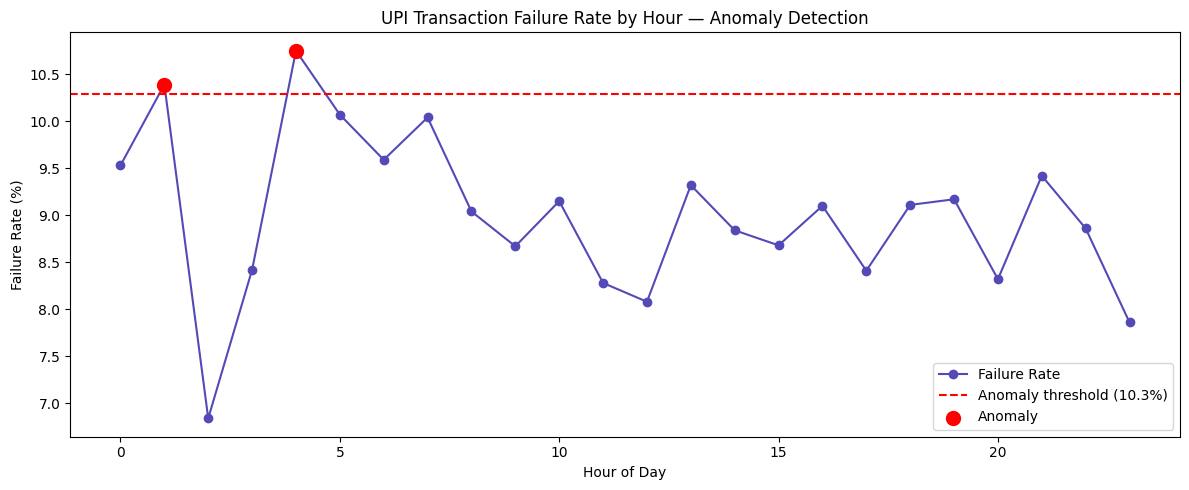

In [8]:
import matplotlib.pyplot as plt

# Calculate failure rate per hour
hourly = pd.read_sql("""
    SELECT
        hour,
        COUNT(*) as total,
        SUM(CASE WHEN status = 'FAILED' THEN 1 ELSE 0 END) as failed,
        ROUND(100.0 * SUM(CASE WHEN status='FAILED' THEN 1 ELSE 0 END)/COUNT(*), 2) as failure_rate
    FROM transactions
    GROUP BY hour
    ORDER BY hour
""", conn)

# Calculate mean and standard deviation
mean_rate = hourly["failure_rate"].mean()
std_rate  = hourly["failure_rate"].std()
threshold = mean_rate + 1.5 * std_rate

# Flag anomalous hours
hourly["is_anomaly"] = hourly["failure_rate"] > threshold

print(f"Average failure rate : {mean_rate:.2f}%")
print(f"Anomaly threshold    : {threshold:.2f}%")
print(f"\nAnomalous hours detected:")
print(hourly[hourly["is_anomaly"]][["hour","failure_rate"]])

# Plot
plt.figure(figsize=(12, 5))
plt.plot(hourly["hour"], hourly["failure_rate"], marker="o", color="#534AB7", label="Failure Rate")
plt.axhline(threshold, color="red", linestyle="--", label=f"Anomaly threshold ({threshold:.1f}%)")
plt.scatter(
    hourly[hourly["is_anomaly"]]["hour"],
    hourly[hourly["is_anomaly"]]["failure_rate"],
    color="red", zorder=5, s=100, label="Anomaly"
)
plt.xlabel("Hour of Day")
plt.ylabel("Failure Rate (%)")
plt.title("UPI Transaction Failure Rate by Hour — Anomaly Detection")
plt.legend()
plt.tight_layout()
plt.savefig("anomaly_detection.png", dpi=150)
plt.show()